In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
class Config:
    device = "cuda" if torch.cuda.is_available() else "cpu"

    n_data_samples = 5000
    batch_size = 256
    hidden_dim = 256

    lr = 1e-3
    epochs = 600

    beta_min = 0.01
    beta_max = 0.5

    num_sampling_steps = 3000
    num_generated_samples = 5000

config = Config()
print(config.device)

cuda


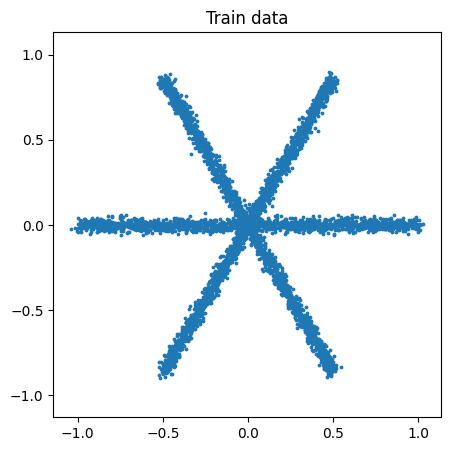

In [3]:
def generate_star_data(n_samples=5000, n_branches=6, noise=0.02, radius=1.0):
    points = []

    samples_per_branch = n_samples // n_branches

    for i in range(n_branches):
        angle = 2 * np.pi * i / n_branches

        direction = np.array([
            np.cos(angle),
            np.sin(angle)
        ])

        lengths = np.random.rand(samples_per_branch, 1) * radius

        branch_points = lengths * direction[None, :]
        branch_points += np.random.randn(samples_per_branch, 2) * noise

        points.append(branch_points)

    points = np.concatenate(points, axis=0).astype(np.float32)

    return points

data_np = generate_star_data(config.n_data_samples)

plt.figure(figsize=(5, 5))
plt.scatter(data_np[:, 0], data_np[:, 1], s=3)
plt.axis("equal")
plt.title("Train data")
plt.show()

In [4]:
def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)

def integral_beta(t, config):
    return config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t**2

def alpha_bar_t(t, config):
    return torch.exp(-integral_beta(t, config))

def marginal_std(t, config):
    return torch.sqrt(1.0 - alpha_bar_t(t, config))

In [5]:
def q_sample(x0, t, config):
    """
    x0: [B, 2]
    t: [B, 1]
    """
    eps = torch.randn_like(x0)

    alpha_bar = alpha_bar_t(t, config)
    mean_coef = torch.sqrt(alpha_bar)
    std = torch.sqrt(1.0 - alpha_bar)

    xt = mean_coef * x0 + std * eps
    return xt, eps

In [6]:
class ScoreModel(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, xt, t):
        t_embed = self.time_mlp(t)
        x = torch.cat([xt, t_embed], dim=1)
        return self.net(x)

In [7]:
class ScoreModel(nn.Module):
    def __init__(self, hidden_dim=128):
        super().__init__()

        self.time_mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        self.net = nn.Sequential(
            nn.Linear(2 + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, xt, t):
        t_embed = self.time_mlp(t)
        x = torch.cat([xt, t_embed], dim=1)
        return self.net(x)

In [8]:
model = ScoreModel(hidden_dim=config.hidden_dim).to(config.device)
optimizer = optim.Adam(model.parameters(), lr=config.lr)
criterion = nn.MSELoss()

In [9]:
def train_one_epoch(model, dataloader, optimizer, config):
    model.train()
    total_loss = 0.0

    for (x0,) in dataloader:
        x0 = x0.to(config.device)

        t = torch.rand(x0.shape[0], 1, device=config.device) ** 2
        xt, eps = q_sample(x0, t, config)

        eps_hat = model(xt, t)
        loss = criterion(eps_hat, eps)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [10]:
data_tensor = torch.tensor(data_np, dtype=torch.float32)
dataset = TensorDataset(data_tensor)
dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=True)

In [11]:
losses = []

for epoch in range(config.epochs):
    loss = train_one_epoch(model, dataloader, optimizer, config)
    losses.append(loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{config.epochs}, loss = {loss:.6f}")

Epoch 20/600, loss = 0.808436
Epoch 40/600, loss = 0.776397
Epoch 60/600, loss = 0.701006
Epoch 80/600, loss = 0.689665
Epoch 100/600, loss = 0.693511
Epoch 120/600, loss = 0.684597
Epoch 140/600, loss = 0.667418
Epoch 160/600, loss = 0.671212
Epoch 180/600, loss = 0.674829
Epoch 200/600, loss = 0.677487
Epoch 220/600, loss = 0.680849
Epoch 240/600, loss = 0.670544
Epoch 260/600, loss = 0.681013
Epoch 280/600, loss = 0.675925
Epoch 300/600, loss = 0.672390
Epoch 320/600, loss = 0.642309
Epoch 340/600, loss = 0.676546
Epoch 360/600, loss = 0.651769
Epoch 380/600, loss = 0.659419
Epoch 400/600, loss = 0.659146
Epoch 420/600, loss = 0.664403
Epoch 440/600, loss = 0.666430
Epoch 460/600, loss = 0.677192
Epoch 480/600, loss = 0.669221
Epoch 500/600, loss = 0.663078
Epoch 520/600, loss = 0.660567
Epoch 540/600, loss = 0.654529
Epoch 560/600, loss = 0.665463
Epoch 580/600, loss = 0.680074
Epoch 600/600, loss = 0.661899


In [12]:
def get_ddpm_schedule(config):
    betas = torch.linspace(
        config.beta_min / config.num_sampling_steps,
        config.beta_max / config.num_sampling_steps,
        config.num_sampling_steps,
        device=config.device
    )

    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)

    return betas, alphas, alpha_bars

In [13]:
@torch.no_grad()
def predict_score(model, xt, t, config):
    eps_hat = model(xt, t)
    std = torch.sqrt(1.0 - alpha_bar_t(t, config))
    score = -eps_hat / std
    return score

In [14]:
@torch.no_grad()
def sample_vpsde(model, config):
    model.eval()

    n = config.num_generated_samples
    device = config.device

    x = torch.randn(n, 2, device=device)

    timesteps = torch.linspace(
        1.0,
        1e-3,
        config.num_sampling_steps,
        device=device
    )

    for i in range(len(timesteps) - 1):

        t = timesteps[i].repeat(n, 1)
        t_next = timesteps[i + 1].repeat(n, 1)

        dt = t_next - t

        beta = beta_t(t, config)

        eps_hat = model(x, t)

        std = torch.sqrt(1.0 - alpha_bar_t(t, config))

        score = -eps_hat / (std + 1e-5)

        drift = -0.5 * beta * x - beta * score

        noise = torch.randn_like(x)

        x = (
            x
            + drift * dt
            + torch.sqrt(beta * (-dt)) * noise
        )

    return x.cpu().numpy()

In [15]:
samples = sample_vpsde(model, config)

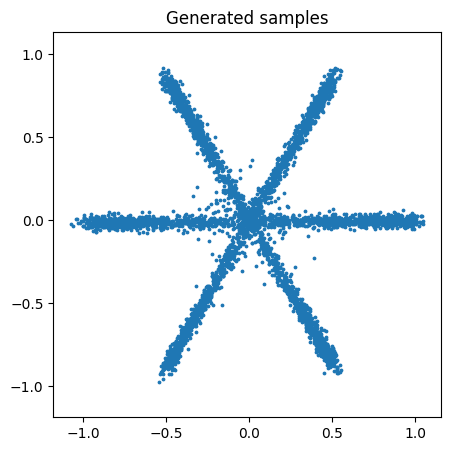

In [16]:
plt.figure(figsize=(5, 5))
plt.scatter(samples[:, 0], samples[:, 1], s=3)
plt.axis("equal")
plt.title("Generated samples")
plt.show()

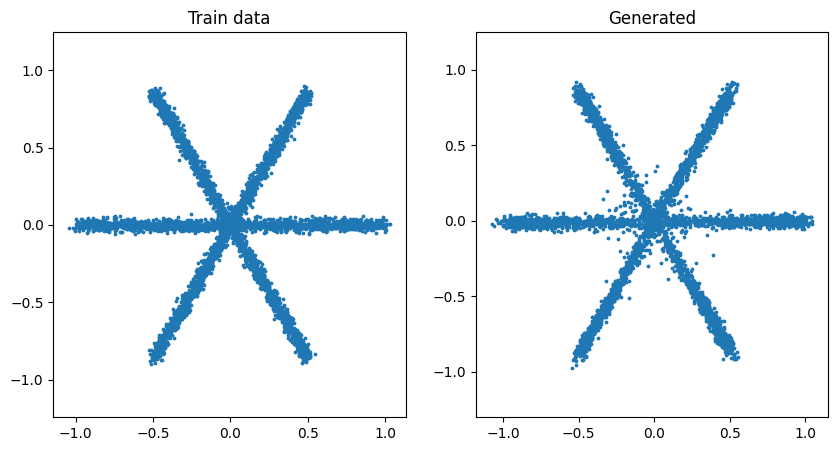

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(data_np[:, 0], data_np[:, 1], s=3)
axes[0].axis("equal")
axes[0].set_title("Train data")

axes[1].scatter(samples[:, 0], samples[:, 1], s=3)
axes[1].axis("equal")
axes[1].set_title("Generated")

plt.show()